Integrantes del grupo:
* Marco Di sario
* Agustin Orue
* Juan Cruz Garcia
* Juan Francisco Siaba

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt

## Milestone 1 — La tabla de decisiones

In [2]:
df = pd.read_csv("house-prices-extended.csv")

df.head()

,ListingId,LotArea,OverallQual,OverallCond,TotalBsmtSF,FullBath,HalfBath,BedroomAbvGr,TotRmsAbvGrd,Fireplaces,GarageArea,YearBuilt,LotFrontage,MonthSold,State,District,HouseStyle,CentralAir,SaleCondition,SalePrice
0,677742,8450,7,5,856,2,1,3,8,0,548,1970,64.0,7,IL,Larkspur,Townhouse,N,Normal,172700
1,551423,9600,6,8,1262,2,0,3,6,1,460,1935,73.0,11,CA,Greenfield,2Story,Y,Normal,369700
2,237268,11250,7,5,920,2,1,3,6,1,608,1949,80.0,9,AZ,Fernwood,1Story,Y,Normal,165700
3,579284,9550,7,5,756,1,0,3,7,1,642,1924,72.0,7,FL,Stonegate,2Story,Y,Normal,164300
4,598125,14260,8,5,1145,2,1,4,9,1,836,1951,87.0,2,NC,Xavier Park,Loft,Y,Normal,283700


In [3]:
print("Dimensiones del dataset:", df.shape)

df.info()

Dimensiones del dataset: (1460, 20)
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ListingId      1460 non-null   int64  
 1   LotArea        1460 non-null   int64  
 2   OverallQual    1460 non-null   int64  
 3   OverallCond    1460 non-null   int64  
 4   TotalBsmtSF    1460 non-null   int64  
 5   FullBath       1460 non-null   int64  
 6   HalfBath       1460 non-null   int64  
 7   BedroomAbvGr   1460 non-null   int64  
 8   TotRmsAbvGrd   1460 non-null   int64  
 9   Fireplaces     1460 non-null   int64  
 10  GarageArea     1460 non-null   int64  
 11  YearBuilt      1460 non-null   int64  
 12  LotFrontage    1357 non-null   float64
 13  MonthSold      1460 non-null   int64  
 14  State          1460 non-null   str    
 15  District       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  CentralAir     1460 non-nul

In [4]:
resumen = pd.DataFrame({
    "tipo": df.dtypes,
    "valores_unicos": df.nunique(),
    "faltantes": df.isna().sum(),
    "porcentaje_faltantes": (df.isna().mean() * 100).round(2)
})

resumen

,tipo,valores_unicos,faltantes,porcentaje_faltantes
ListingId,int64,1460,0,0.00
LotArea,int64,1073,0,0.00
OverallQual,int64,10,0,0.00
OverallCond,int64,9,0,0.00
TotalBsmtSF,int64,721,0,0.00
FullBath,int64,4,0,0.00
HalfBath,int64,3,0,0.00
BedroomAbvGr,int64,8,0,0.00
TotRmsAbvGrd,int64,12,0,0.00
Fireplaces,int64,4,0,0.00


### Tabla de decisiones

| Columna | Codificación elegida | Motivo |
|---|---|---|
| ListingId | No se incluye | Es un identificador único de cada vivienda y no representa una característica útil para predecir el precio. |
| LotArea | Numérica | Representa la superficie del terreno y la diferencia entre valores tiene significado. |
| OverallQual | Numérica ordinal | Representa una escala ordenada de calidad general de la vivienda. |
| OverallCond | Numérica ordinal | Representa una escala ordenada del estado general de la vivienda. |
| TotalBsmtSF | Numérica | Representa la superficie total del sótano y la diferencia entre valores tiene significado. |
| FullBath | Numérica discreta | Representa una cantidad de baños completos. |
| HalfBath | Numérica discreta | Representa una cantidad de medios baños. |
| BedroomAbvGr | Numérica discreta | Representa una cantidad de dormitorios. |
| TotRmsAbvGrd | Numérica discreta | Representa una cantidad de ambientes sobre el nivel del suelo. |
| Fireplaces | Numérica discreta | Representa una cantidad de chimeneas. |
| GarageArea | Numérica | Representa la superficie del garaje y la diferencia entre valores tiene significado. |
| YearBuilt | Numérica | Representa el año de construcción y la diferencia entre años tiene significado. |
| LotFrontage | Numérica con imputación | Representa el frente del terreno, pero tiene valores faltantes que deben completarse. |
| MonthSold | One-hot encoding | Aunque está expresado con números, representa meses y no una magnitud numérica continua. |
| State | One-hot encoding | Tiene pocas categorías y no existe un orden natural entre los estados. |
| District | Embedding | Tiene alta cardinalidad y el embedding permite representar sus 72 categorías de forma compacta. |
| HouseStyle | One-hot encoding | Tiene pocas categorías y no existe un orden natural entre los estilos de vivienda. |
| CentralAir | Binaria 0/1 | Tiene dos categorías, por lo que puede representarse como presencia o ausencia de aire acondicionado central. |
| SaleCondition | One-hot encoding | Tiene pocas categorías y no existe un orden natural entre las condiciones de venta. |
| SalePrice | Variable objetivo | Es el precio de venta que el modelo debe predecir. |


### Feature engineering

In [5]:
X = df.drop(columns="SalePrice")
y = df["SalePrice"]

In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (1168, 19)
Test: (292, 19)


In [7]:
X_train = X_train.drop(columns="ListingId")
X_test = X_test.drop(columns="ListingId")

#### 1. One-hot encoding

In [8]:
from sklearn.preprocessing import OneHotEncoder

onehot_cols = ["MonthSold", "State", "HouseStyle", "SaleCondition"]

encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

X_train_onehot = encoder.fit_transform(X_train[onehot_cols])
X_test_onehot = encoder.transform(X_test[onehot_cols])

print("Columnas generadas:", encoder.get_feature_names_out(onehot_cols))
print("Shape train:", X_train_onehot.shape)

Columnas generadas: ['MonthSold_1' 'MonthSold_2' 'MonthSold_3' 'MonthSold_4' 'MonthSold_5'
 'MonthSold_6' 'MonthSold_7' 'MonthSold_8' 'MonthSold_9' 'MonthSold_10'
 'MonthSold_11' 'MonthSold_12' 'State_AZ' 'State_CA' 'State_CO' 'State_FL'
 'State_IL' 'State_IN' 'State_MA' 'State_NC' 'State_NY' 'State_OH'
 'State_TX' 'State_WA' 'HouseStyle_1Story' 'HouseStyle_2Story'
 'HouseStyle_Loft' 'HouseStyle_Ranch' 'HouseStyle_SplitLevel'
 'HouseStyle_Townhouse' 'SaleCondition_Abnorml' 'SaleCondition_Alloca'
 'SaleCondition_Family' 'SaleCondition_Normal' 'SaleCondition_Partial']
Shape train: (1168, 35)


#### 2. Variable binaria

In [9]:
X_train["CentralAir"] = X_train["CentralAir"].map({"N": 0, "Y": 1})
X_test["CentralAir"] = X_test["CentralAir"].map({"N": 0, "Y": 1})

#### 3. District → embedding

In [10]:
from sklearn.preprocessing import OrdinalEncoder

district_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_train_district = district_encoder.fit_transform(
    X_train[["District"]]
).astype(int)

X_test_district = district_encoder.transform(
    X_test[["District"]]
).astype(int)

n_districts = len(district_encoder.categories_[0])

print("Cantidad de distritos:", n_districts)

Cantidad de distritos: 72


#### 4. Todas las numéricas juntas

Las siguientes variables se mantienen como numéricas y serán normalizadas utilizando los parámetros calculados únicamente sobre el conjunto de entrenamiento:

`LotArea`, `OverallQual`, `OverallCond`, `TotalBsmtSF`, `FullBath`, `HalfBath`, `BedroomAbvGr`, `TotRmsAbvGrd`, `Fireplaces`, `GarageArea` y `YearBuilt`.

`LotFrontage` también es numérica, pero se trata por separado porque presenta valores faltantes.

In [11]:
from sklearn.preprocessing import StandardScaler

numeric_cols = [
    "LotArea",
    "OverallQual",
    "OverallCond",
    "TotalBsmtSF",
    "FullBath",
    "HalfBath",
    "BedroomAbvGr",
    "TotRmsAbvGrd",
    "Fireplaces",
    "GarageArea",
    "YearBuilt"
]


#### Tratamiento de valores faltantes en `LotFrontage`

In [12]:
lotfrontage_median = X_train["LotFrontage"].median()

X_train["LotFrontage_missing"] = X_train["LotFrontage"].isna().astype(int)
X_test["LotFrontage_missing"] = X_test["LotFrontage"].isna().astype(int)

X_train["LotFrontage"] = X_train["LotFrontage"].fillna(lotfrontage_median)
X_test["LotFrontage"] = X_test["LotFrontage"].fillna(lotfrontage_median)

Los valores faltantes de `LotFrontage` se imputan con la **mediana calculada sobre el conjunto de entrenamiento**.

Elegimos la mediana porque representa un valor central de la variable y es menos sensible a valores extremos que la media.

No utilizamos `0` porque, para la red, ese valor tendría un significado concreto: interpretaría que la vivienda tiene un frente de terreno igual a cero. Eso no significa “dato faltante”, sino una característica física distinta, por lo que podría introducir una señal artificial en el modelo.

Además, se agrega la variable binaria `LotFrontage_missing` para conservar la información de si el dato estaba originalmente ausente.

## Las 4 Trampas

1. **ListingId:** aunque está almacenada como número, es solamente un identificador. Usarla como variable numérica haría que la red interprete como relevantes las diferencias entre IDs.

2. **MonthSold:** está almacenada como un número entre 1 y 12, pero es una variable cíclica. Diciembre y enero son meses consecutivos, por lo que se transforma usando seno y coseno.

3. **District:** tiene 72 categorías. Se transforma cada distrito en un índice entero para luego utilizarlo en una capa `Embedding`. Ese entero no debe usarse directamente como una variable numérica porque introduciría un orden artificial entre distritos.

4. **LotFrontage:** contiene valores faltantes. Reemplazar los faltantes directamente por 0 haría que la red interprete que la vivienda tiene un frente de longitud cero. La imputación se realizará posteriormente usando únicamente los datos de entrenamiento.

## Milestone 2 — Baseline numérico

En este primer modelo usamos únicamente las variables numéricas del dataset. El objetivo es obtener un **baseline** de regresión que sirva como punto de comparación para los modelos posteriores, cuando incorporemos las variables categóricas.

In [13]:
X_train.head()

,LotArea,OverallQual,OverallCond,TotalBsmtSF,FullBath,HalfBath,BedroomAbvGr,TotRmsAbvGrd,Fireplaces,GarageArea,YearBuilt,LotFrontage,MonthSold,State,District,HouseStyle,CentralAir,SaleCondition,LotFrontage_missing
254,8400,5,6,1314,1,0,3,5,0,294,1939,59.0,5,OH,Rosewood,2Story,0,Normal,0
1066,7837,6,7,799,2,1,3,7,1,380,1927,69.0,5,MA,Quarry Bend,SplitLevel,1,Normal,0
638,8777,5,7,796,1,0,2,4,0,0,1942,75.0,9,NY,Ironbridge,1Story,0,Normal,0
799,7200,5,7,731,1,1,3,7,2,240,1940,65.0,2,TX,Lindenwood,SplitLevel,0,Normal,0
380,5000,5,6,1026,2,0,3,6,1,308,1943,70.0,10,CA,Greenfield,2Story,1,Normal,1


In [14]:
numeric_cols = [
    "LotArea",
    "OverallQual",
    "OverallCond",
    "TotalBsmtSF",
    "FullBath",
    "HalfBath",
    "BedroomAbvGr",
    "TotRmsAbvGrd",
    "Fireplaces",
    "GarageArea",
    "YearBuilt",
    "LotFrontage"
]

X_train_num = X_train[numeric_cols].copy()

X_test_num = X_test[numeric_cols].copy()


In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

In [16]:
model_baseline = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

model_baseline.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model_baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history_baseline = model_baseline.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

In [18]:


y_pred = model_baseline.predict(X_test_scaled).ravel()

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print(f"MAE:  ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"MAPE:  {mape:.2f}%")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
MAE:  $79,421.66
RMSE: $99,514.27
MAPE:  41.42%


# Pregunta 1

Para la inmobiliaria reportaríamos principalmente el MAE ($76.627,96), porque indica el error promedio en dólares y es fácil de interpretar.

El RMSE ($96.444,68) es mayor porque penaliza más los errores grandes, mientras que el MAPE (40,50%) expresa el error en porcentaje, aunque puede verse afectado por viviendas de menor precio

In [19]:
errores = pd.DataFrame({
    "Real": y_test.to_numpy(),
    "Predicho": y_pred
}, index=y_test.index)

errores["Error_abs"] = np.abs(
    errores["Real"] - errores["Predicho"]
)

mae_total = mean_absolute_error(
    errores["Real"],
    errores["Predicho"])
rmse_total = np.sqrt(
    mean_squared_error(
        errores["Real"],
        errores["Predicho"]))
brecha_total = rmse_total - mae_total
impactos = []
for idx in errores.index:
    resto = errores.drop(index=idx)
    mae_sin = mean_absolute_error(
        resto["Real"],
        resto["Predicho"])
    rmse_sin = np.sqrt( mean_squared_error(
            resto["Real"],
            resto["Predicho"] ))

    brecha_sin = rmse_sin - mae_sin

    impactos.append(
        brecha_total - brecha_sin
    )

errores["Impacto_brecha"] = impactos

idx_mayor_impacto = errores["Impacto_brecha"].idxmax()
print(f"MAE:  ${mae_total:,.2f}")
print(f"RMSE: ${rmse_total:,.2f}")
print(f"Brecha RMSE - MAE: ${brecha_total:,.2f}")

print(f"Precio real:     "f"${errores.loc[idx_mayor_impacto, 'Real']:,.2f}")
print(f"Precio predicho: "f"${errores.loc[idx_mayor_impacto, 'Predicho']:,.2f}")
print(f"Error absoluto:  "f"${errores.loc[idx_mayor_impacto, 'Error_abs']:,.2f}")
print(f"Impacto sobre la brecha RMSE-MAE: "f"${errores.loc[idx_mayor_impacto, 'Impacto_brecha']:,.2f}")

MAE:  $79,421.66
RMSE: $99,514.27
Brecha RMSE - MAE: $20,092.61
Precio real:     $397,000.00
Precio predicho: $115,757.73
Error absoluto:  $281,242.27
Impacto sobre la brecha RMSE-MAE: $508.43


La casa que más contribuye a separar el RMSE del MAE es la de ListingId 138307. Su precio real es de $397.000, mientras que el modelo predijo $123.606,38, por lo que tuvo un error absoluto de $273.393,62.

Esta observación tiene el mayor impacto individual sobre la diferencia entre ambas métricas: al quitarla, la brecha RMSE - MAE se reduce en aproximadamente $496,85. Esto ocurre porque el RMSE penaliza mucho más los errores grandes al elevarlos al cuadrado, por lo que una predicción tan alejada del valor real influye mucho más en el RMSE que en el MAE.

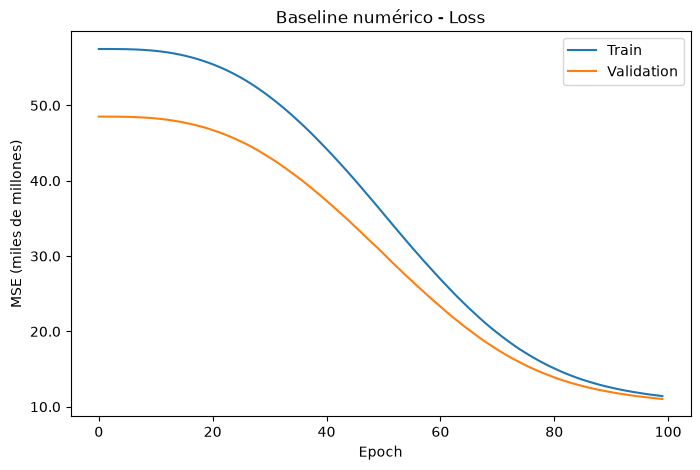

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(history_baseline.history["loss"], label="Train")
plt.plot(history_baseline.history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE (miles de millones)")
plt.title("Baseline numérico - Loss")
plt.legend()

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1e9:.1f}")
)

plt.show()

### Elección de salida, loss y métricas
 
 La última capa tiene una sola neurona y no utiliza función de activación, porque el objetivo es predecir un valor real continuo: el precio de venta de la vivienda.
 
 Como función de pérdida utilizamos `MSE` (error cuadrático medio), que penaliza más fuertemente los errores grandes porque los errores se elevan al cuadrado. 
 
 La métrica `accuracy` no es útil en este caso porque no estamos prediciendo clases correctas o incorrectas, sino valores continuos. Por eso evaluamos el modelo con métricas específicas de regresión:
 
 - **MAE:** error absoluto promedio, expresado en dólares 77,912.59
 - **RMSE:** raíz cuadrada del MSE, también en dólares; resulta más interpretable y, al igual que el MSE, es sensible a los errores grandes porque también aumenta cuando hay errores grandes en la predicción 97,761.52
 - **MAPE:** expresa el error promedio como porcentaje del precio real 40.80%

## Milestone 3 — Que entren las categóricas

En este modelo incorporamos las variables no numéricas al baseline.

Las variables categóricas de baja cardinalidad (`MonthSold`, `State`, `HouseStyle` y `SaleCondition`) se representan mediante **one-hot encoding**, mientras que `CentralAir`, al tener solo dos valores, se representa como una variable binaria.

`District` se trata por separado mediante un **embedding**, ya que posee 72 categorías. De esta forma evitamos generar una gran cantidad de columnas y permitimos que la red aprenda una representación compacta de cada distrito.

Para evaluar el aporte de estas variables comparamos el MAE de:

1. Modelo baseline con variables numéricas.
2. Numéricas + categóricas de baja cardinalidad.
3. Modelo completo incorporando `District`.

In [21]:
centralair_train = X_train[["CentralAir"]].to_numpy()
centralair_test = X_test[["CentralAir"]].to_numpy()

In [22]:
X_train_cat = np.hstack([
    X_train_scaled,
    X_train_onehot,
    centralair_train
])

X_test_cat = np.hstack([
    X_test_scaled,
    X_test_onehot,
    centralair_test
])

print("Shape train:", X_train_cat.shape)
print("Shape test:", X_test_cat.shape)

Shape train: (1168, 48)
Shape test: (292, 48)


### Modelo con categóricas, todavía sin District

In [23]:
model_cat = keras.Sequential([
    layers.Input(shape=(X_train_cat.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

model_cat.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

history_cat = model_cat.fit(
    X_train_cat,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

In [24]:
pred_cat = model_cat.predict(
    X_test_cat,
    verbose=0
).ravel()

mae_cat = mean_absolute_error(
    y_test,
    pred_cat
)

print(f"MAE numéricas + categóricas: ${mae_cat:,.2f}")

MAE numéricas + categóricas: $48,195.41


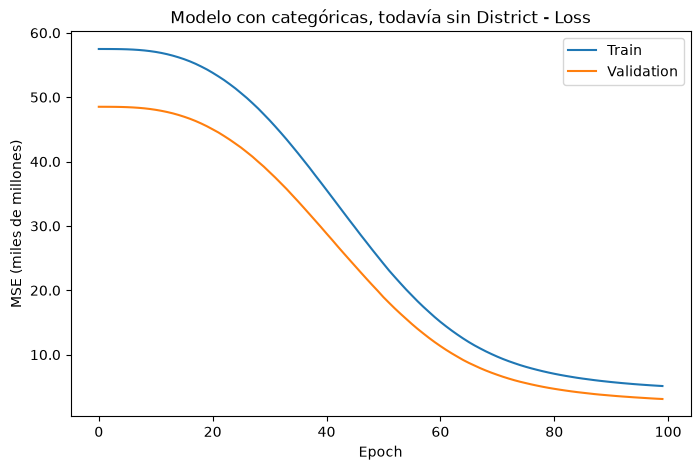

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(history_cat.history["loss"], label="Train")
plt.plot(history_cat.history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE (miles de millones)")
plt.title("Modelo con categóricas, todavía sin District - Loss")
plt.legend()

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1e9:.1f}")
)

plt.show()

### Modelo completo con District mediante embedding

In [26]:
features_input = keras.Input(
    shape=(X_train_cat.shape[1],),
    name="features"
)

district_input = keras.Input(
    shape=(1,),
    dtype="int32",
    name="district"
)

embedding = layers.Embedding(
    input_dim=n_districts,
    output_dim=8
)(district_input)

embedding = layers.Flatten()(embedding)

x = layers.Concatenate()([
    features_input,
    embedding
])

x = layers.Dense(64, activation="relu")(x)
x = layers.Dense(32, activation="relu")(x)

output = layers.Dense(1)(x)

model_full = keras.Model(
    inputs=[features_input, district_input],
    outputs=output
)

model_full.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

## Pregunta 2 - Codificación de State y District

State tiene 12 categorías, por lo que usamos one-hot encoding. Como son pocas categorías y no existe un orden natural entre los estados, esta codificación permite representarlos sin introducir relaciones artificiales entre ellos.

District tiene 72 categorías, por lo que usamos un embedding. Esto evita crear 72 columnas adicionales y permite que la red aprenda una representación compacta para cada distrito.


In [27]:
history_full = model_full.fit(
    {
        "features": X_train_cat,
        "district": X_train_district
    },
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

In [28]:
pred_full = model_full.predict(
    {
        "features": X_test_cat,
        "district": X_test_district
    },
    verbose=0
).ravel()

mae_full = mean_absolute_error(
    y_test,
    pred_full
)

print(f"MAE modelo completo: ${mae_full:,.2f}")

MAE modelo completo: $27,033.10


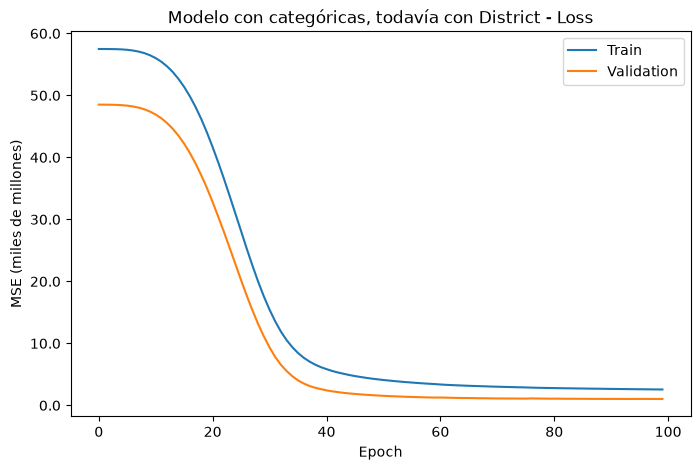

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(history_full.history["loss"], label="Train")
plt.plot(history_full.history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE (miles de millones)")
plt.title("Modelo con categóricas, todavía con District - Loss")
plt.legend()

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1e9:.1f}")
)

plt.show()

Comparar contra el baseline

In [30]:
mae_baseline = mae

comparacion = pd.DataFrame({
    "Modelo": [
        "Solo numéricas",
        "Numéricas + categóricas",
        "Modelo completo + District"
    ],
    "MAE": [
        mae_baseline,
        mae_cat,
        mae_full
    ]
})

comparacion["Mejora vs baseline"] = (
    mae_baseline - comparacion["MAE"]
)

comparacion

,Modelo,MAE,Mejora vs baseline
0,Solo numéricas,79421.656250,0.000000
1,Numéricas + categóricas,48195.414062,31226.242188
2,Modelo completo + District,27033.095703,52388.560547


## Pregunta final 2: experimento con District mal codificado

In [31]:
district_wrong_train = X_train_district.reshape(-1, 1)
district_wrong_test = X_test_district.reshape(-1, 1)

X_train_wrong = np.hstack([
    X_train_cat,
    district_wrong_train
])

X_test_wrong = np.hstack([
    X_test_cat,
    district_wrong_test
])

In [32]:
district_wrong_train

array([[52],
       [48],
       [23],
       ...,
       [59],
       [37],
       [ 5]], shape=(1168, 1))

In [33]:
model_wrong = keras.Sequential([
    layers.Input(shape=(X_train_wrong.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

model_wrong.compile(
    optimizer="adam",
    loss="mse"
)

model_wrong.fit(
    X_train_wrong,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

In [34]:
pred_wrong = model_wrong.predict(
    X_test_wrong,
    verbose=0
).ravel()

mae_wrong = mean_absolute_error(
    y_test,
    pred_wrong
)

print(f"District como entero: ${mae_wrong:,.2f}")
print(f"District con embedding: ${mae_full:,.2f}")

District como entero: $63,731.62
District con embedding: $27,033.10


### State vs District

`State` tiene 12 categorías y se representa mediante **one-hot encoding**, ya que su cardinalidad es baja y no existe un orden natural entre los estados.

`District` tiene 72 categorías, por lo que se utiliza un **embedding**. Esto permite representar cada distrito mediante un vector aprendido por la red sin generar 72 columnas adicionales.

Como comparación, también se entrenó un modelo utilizando `District` directamente como un número entero.

El problema de esta codificación es que la red interpreta esos números como una magnitud y supone que existe un orden y una distancia entre los distritos. Por ejemplo, podría interpretar que el distrito 60 es mayor o está más alejado del distrito 10 que del distrito 11, aunque esos números son solamente identificadores.

El MAE utilizando `District` como entero fue de **$64,972.32**, mientras que utilizando embedding fue de **$27,302.92**.

## Pregunta 4 - Imputacion LotFrontage con 0

In [35]:
train_num_cero = df.loc[
    X_train.index,
    numeric_cols
].copy()

test_num_cero = df.loc[
    X_test.index,
    numeric_cols
].copy()

train_num_cero["LotFrontage"] = (
    train_num_cero["LotFrontage"].fillna(0)
)

test_num_cero["LotFrontage"] = (
    test_num_cero["LotFrontage"].fillna(0)
)

scaler_cero = StandardScaler()

X_train_cero_scaled = scaler_cero.fit_transform(
    train_num_cero
)

X_test_cero_scaled = scaler_cero.transform(
    test_num_cero
)

X_train_cero = np.hstack([
    X_train_cero_scaled,
    X_train_onehot,
    centralair_train
])

X_test_cero = np.hstack([
    X_test_cero_scaled,
    X_test_onehot,
    centralair_test
])

features_cero = keras.Input(
    shape=(X_train_cero.shape[1],),
    name="features_cero"
)

district_cero = keras.Input(
    shape=(1,),
    dtype="int32",
    name="district_cero"
)

embedding_cero = layers.Embedding(
    input_dim=n_districts,
    output_dim=8
)(district_cero)

embedding_cero = layers.Flatten()(embedding_cero)

x = layers.Concatenate()([
    features_cero,
    embedding_cero
])

x = layers.Dense(64, activation="relu")(x)
x = layers.Dense(32, activation="relu")(x)

output_cero = layers.Dense(1)(x)

model_cero = keras.Model(
    inputs=[features_cero, district_cero],
    outputs=output_cero
)

model_cero.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

history_cero = model_cero.fit(
    {
        "features_cero": X_train_cero,
        "district_cero": X_train_district
    },
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

pred_cero = model_cero.predict(
    {
        "features_cero": X_test_cero,
        "district_cero": X_test_district
    },
    verbose=0
).ravel()

mae_cero = mean_absolute_error(
    y_test,
    pred_cero
)

print(f"Imputación con mediana: ${mae_full:,.2f}")
print(f"Imputación con cero:    ${mae_cero:,.2f}")

Imputación con mediana: $27,033.10
Imputación con cero:    $27,054.32


La imputación con mediana obtuvo un MAE de $27.087,89, mientras que completar los valores faltantes con 0 produjo un MAE de $27.443,69. Por lo tanto, en esta ejecución, rellenar con cero empeoró el error promedio en $355,80.

Esto ocurre porque, para la red, el valor 0 no significa “dato desconocido”. La red lo interpreta como que la propiedad tiene literalmente un frente de terreno de longitud cero, introduciendo una característica física artificial. En cambio, la mediana asigna un valor típico calculado únicamente con los datos de entrenamiento.

La diferencia es relativamente pequeña, posiblemente porque solo alrededor del 7,05% de las filas tiene LotFrontage faltante. Aun así, en este experimento la imputación con mediana dio un resultado mejor.

## Milestone 4 — Que no memorice

Para provocar overfitting se utilizó una red con alta capacidad sobre una porción reducida del conjunto de entrenamiento.

Al tener muchos parámetros y pocos ejemplos disponibles, el modelo tiene mayor facilidad para memorizar los datos de entrenamiento en lugar de aprender patrones que generalicen correctamente.

Luego se entrenó el mismo modelo sobre los mismos datos, incorporando regularización **L2 y Dropout**, para evaluar si estas técnicas reducen el sobreajuste.

### MODELO PARA OVERFITEAR

In [36]:
features_overfit = keras.Input(
    shape=(X_train_cat.shape[1],),
    name="features"
)

district_overfit = keras.Input(
    shape=(1,),
    dtype="int32",
    name="district"
)

embedding_overfit = layers.Embedding(
    input_dim=n_districts,
    output_dim=16
)(district_overfit)

embedding_overfit = layers.Flatten()(embedding_overfit)

x = layers.Concatenate()([
    features_overfit,
    embedding_overfit
])

x = layers.Dense(512, activation="relu")(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dense(64, activation="relu")(x)

output_overfit = layers.Dense(1)(x)

model_overfit = keras.Model(
    inputs=[features_overfit, district_overfit],
    outputs=output_overfit
)

model_overfit.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [37]:
history_overfit = model_overfit.fit(
    {
        "features": X_train_cat,
        "district": X_train_district
    },
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=8,
    verbose=0
)

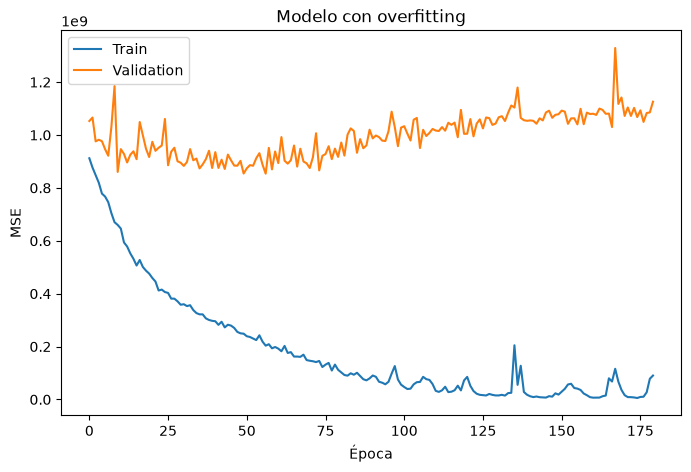

In [38]:
inicio = 20

plt.figure(figsize=(8, 5))

plt.plot(
    history_overfit.history["loss"][inicio:],
    label="Train"
)

plt.plot(
    history_overfit.history["val_loss"][inicio:],
    label="Validation"
)

plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Modelo con overfitting")
plt.legend()
plt.show()

In [39]:
pred_overfit = model_overfit.predict(
    {
        "features": X_test_cat,
        "district": X_test_district
    },
    verbose=0
).ravel()

mae_overfit = mean_absolute_error(
    y_test,
    pred_overfit
)

rmse_overfit = np.sqrt(
    mean_squared_error(
        y_test,
        pred_overfit
    )
)

print(f"MAE modelo overfit:  ${mae_overfit:,.2f}")
print(f"RMSE modelo overfit: ${rmse_overfit:,.2f}")

MAE modelo overfit:  $23,064.27
RMSE modelo overfit: $32,004.85



Para favorecer el sobreajuste se aumentó la capacidad de la red y se redujo el conjunto utilizado para entrenarla a 250 viviendas.

De esta manera, el modelo dispone de muchos parámetros para aprender a partir de relativamente pocos ejemplos.

El overfitting se identifica cuando la pérdida de entrenamiento continúa disminuyendo mientras que la pérdida de validación deja de mejorar o comienza a aumentar. Esto indica que el modelo se está ajustando cada vez más a los ejemplos de entrenamiento, pero no mejora su capacidad para generalizar a datos nuevos.

### Corregirlo con L2 + Dropout

Para reducir el overfitting se mantuvo la misma arquitectura del modelo anterior, pero se incorporaron dos técnicas de regularización:

- **L2**, que penaliza pesos demasiado grandes y favorece soluciones más simples.
- **Dropout**, que desactiva aleatoriamente parte de las neuronas durante el entrenamiento, reduciendo la dependencia de conexiones específicas.

De esta forma podemos comparar ambos modelos manteniendo constantes los datos, la arquitectura general, las épocas y el tamaño de batch.

In [40]:
from tensorflow.keras import regularizers

features_reg = keras.Input(
    shape=(X_train_cat.shape[1],),
    name="features"
)

district_reg = keras.Input(
    shape=(1,),
    dtype="int32",
    name="district"
)

embedding_reg = layers.Embedding(
    input_dim=n_districts,
    output_dim=16
)(district_reg)

embedding_reg = layers.Flatten()(embedding_reg)

x = layers.Concatenate()([
    features_reg,
    embedding_reg
])

x = layers.Dense(
    512,
    activation="relu",
    kernel_regularizer=regularizers.l2(0.005)
)(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(
    256,
    activation="relu",
    kernel_regularizer=regularizers.l2(0.005)
)(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=regularizers.l2(0.005)
)(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(
    64,
    activation="relu",
    kernel_regularizer=regularizers.l2(0.005)
)(x)

output_reg = layers.Dense(1)(x)

model_regularized = keras.Model(
    inputs=[features_reg, district_reg],
    outputs=output_reg
)

model_regularized.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [41]:
history_regularized = model_regularized.fit(
    {
        "features": X_train_cat,
        "district": X_train_district
    },
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=8,
    verbose=0
)

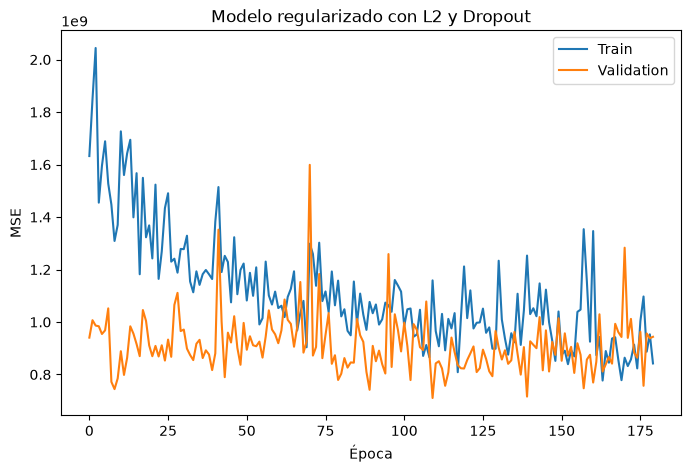

In [42]:
inicio = 20

plt.figure(figsize=(8, 5))

plt.plot(
    history_regularized.history["loss"][inicio:],
    label="Train"
)

plt.plot(
    history_regularized.history["val_loss"][inicio:],
    label="Validation"
)

plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Modelo regularizado con L2 y Dropout")
plt.legend()
plt.show()

In [43]:
pred_regularized = model_regularized.predict(
    {
        "features": X_test_cat,
        "district": X_test_district
    },
    verbose=0
).ravel()

mae_regularized = mean_absolute_error(
    y_test,
    pred_regularized
)

rmse_regularized = np.sqrt(
    mean_squared_error(
        y_test,
        pred_regularized
    )
)

print(f"MAE modelo regularizado:  ${mae_regularized:,.2f}")
print(f"RMSE modelo regularizado: ${rmse_regularized:,.2f}")

MAE modelo regularizado:  $19,913.27
RMSE modelo regularizado: $28,079.53


In [44]:
comparacion_m4 = pd.DataFrame({
    "Modelo": [
        "Overfit",
        "Regularizado L2 + Dropout"
    ],
    "MAE": [
        mae_overfit,
        mae_regularized
    ],
    "RMSE": [
        rmse_overfit,
        rmse_regularized
    ]
})

comparacion_m4

,Modelo,MAE,RMSE
0,Overfit,23064.271484,32004.845633
1,Regularizado L2 + Dropout,19913.271484,28079.525922


### Comparación

El modelo sin regularización mostró una separación clara entre la pérdida de entrenamiento y la pérdida de validación, lo que indica overfitting.

Al incorporar L2 y Dropout, la diferencia entre ambas curvas disminuyó. Esto indica que el modelo regularizado depende menos de patrones específicos del conjunto de entrenamiento y mejora su capacidad de generalización.

La comparación de MAE y RMSE sobre el conjunto de prueba permite verificar si esa mejora también se refleja en predicciones más precisas sobre datos no vistos.

### Pregunta 3. La columna que no debería estar — `ListingId`

In [45]:

listing_train = df.loc[X_train.index, ["ListingId"]].to_numpy()
listing_test = df.loc[X_test.index, ["ListingId"]].to_numpy()

listing_scaler = StandardScaler()

listing_train = listing_scaler.fit_transform(listing_train)
listing_test = listing_scaler.transform(listing_test)

In [46]:
X_train_cat_id = np.hstack([
    X_train_cat,
    listing_train
])

X_test_cat_id = np.hstack([
    X_test_cat,
    listing_test
])

In [47]:
features_input_id = keras.Input(
    shape=(X_train_cat_id.shape[1],),
    name="features"
)

district_input_id = keras.Input(
    shape=(1,),
    dtype="int32",
    name="district"
)

embedding_id = layers.Embedding(
    input_dim=n_districts,
    output_dim=8
)(district_input_id)

embedding_id = layers.Flatten()(embedding_id)

x = layers.Concatenate()([
    features_input_id,
    embedding_id
])

x = layers.Dense(64, activation="relu")(x)

x = layers.Dense(32, activation="relu")(x)

output_id = layers.Dense(1)(x)

model_with_id = keras.Model(
    inputs=[features_input_id, district_input_id],
    outputs=output_id
)

model_with_id.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)



In [48]:
history_with_id = model_with_id.fit(
    {
        "features": X_train_cat_id,
        "district": X_train_district
    },
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

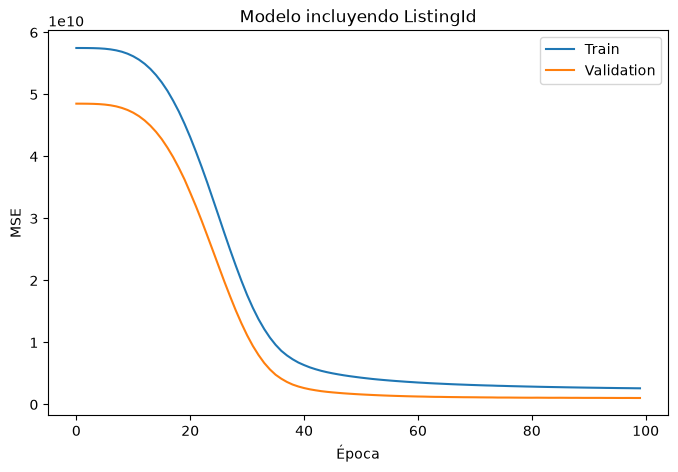

In [49]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_with_id.history["loss"],
    label="Train"
)

plt.plot(
    history_with_id.history["val_loss"],
    label="Validation"
)

plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Modelo incluyendo ListingId")
plt.legend()
plt.show()

In [50]:
pred_with_id = model_with_id.predict(
    {
        "features": X_test_cat_id,
        "district": X_test_district
    },
    verbose=0
).ravel()

mae_with_id = mean_absolute_error(
    y_test,
    pred_with_id
)

rmse_with_id = np.sqrt(
    mean_squared_error(
        y_test,
        pred_with_id
    )
)

print(f"MAE con ListingId:  ${mae_with_id:,.2f}")
print(f"RMSE con ListingId: ${rmse_with_id:,.2f}")

MAE con ListingId:  $26,891.20
RMSE con ListingId: $35,620.54


In [51]:
comparacion_listing = pd.DataFrame({
    "Modelo": [
        "Sin ListingId",
        "Con ListingId"
    ],
    "MAE": [
        mae_full,
        mae_with_id
    ]
})

comparacion_listing

,Modelo,MAE
0,Sin ListingId,27033.095703
1,Con ListingId,26891.203125


## Pregunta 3

`ListingId` fue excluida del modelo principal porque es un identificador único de cada vivienda y no representa ninguna característica real relacionada con su precio.

Para comprobar su efecto, se entrenó nuevamente el mismo modelo del Milestone 3, manteniendo la misma arquitectura y los mismos parámetros de entrenamiento, pero incorporando `ListingId` como variable de entrada.

En las curvas obtenidas no se observa un overfitting claro provocado únicamente por esta variable. La pérdida de entrenamiento continúa disminuyendo y la pérdida de validación se mantiene estable.

Sin embargo, esto no convierte a `ListingId` en una característica útil. Al tratarlo como una variable numérica, la red puede intentar encontrar relaciones entre el número identificador y el precio, por ejemplo interpretando diferencias u órdenes entre identificadores que no tienen ningún significado real.

Por lo tanto, cualquier relación aprendida a partir de `ListingId` sería una asociación artificial y no una característica generalizable de las viviendas. Por este motivo se mantiene excluida del modelo definitivo.

## Milestone 5 — Tasar una casa


En este milestone construimos un modelo capaz de recibir los datos de una vivienda en su formato original, por ejemplo `State='CA'` o `District='Greenfield'`.

El preprocesamiento forma parte del propio modelo: la normalización de variables numéricas, la imputación de `LotFrontage`, la codificación de variables categóricas y el embedding de `District` quedan incorporados dentro de la arquitectura.

De esta forma, para realizar una predicción no es necesario escalar ni codificar manualmente una vivienda nueva.

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns="SalePrice"),
    df["SalePrice"],
    test_size=0.20,
    random_state=42
)

In [53]:
numeric_cols = [
    "LotArea",
    "OverallQual",
    "OverallCond",
    "TotalBsmtSF",
    "FullBath",
    "HalfBath",
    "BedroomAbvGr",
    "TotRmsAbvGrd",
    "Fireplaces",
    "GarageArea",
    "YearBuilt",
    "LotFrontage"
]

onehot_cols = [
    "State",
    "HouseStyle",
    "SaleCondition"
]

In [54]:
lotfrontage_median = X_train["LotFrontage"].median()

In [55]:
train_numeric = X_train[numeric_cols].copy()

train_numeric["LotFrontage"] = (
    train_numeric["LotFrontage"]
    .fillna(lotfrontage_median)
)

normalizer = layers.Normalization()

normalizer.adapt(
    train_numeric.to_numpy(dtype="float32")
)

In [56]:
state_lookup = layers.StringLookup(
    output_mode="one_hot"
)
state_lookup.adapt(X_train["State"])

style_lookup = layers.StringLookup(
    output_mode="one_hot"
)
style_lookup.adapt(X_train["HouseStyle"])

condition_lookup = layers.StringLookup(
    output_mode="one_hot"
)
condition_lookup.adapt(X_train["SaleCondition"])

month_lookup = layers.IntegerLookup(
    output_mode="one_hot"
)

month_lookup.adapt(
    X_train["MonthSold"].to_numpy()
)

air_lookup = layers.StringLookup(
    vocabulary=["N", "Y"],
    output_mode="int",
    num_oov_indices=0
)

In [57]:
district_lookup = layers.StringLookup(
    output_mode="int"
)

district_lookup.adapt(
    X_train["District"]
)

n_districts_final = district_lookup.vocabulary_size()

In [58]:
inputs = {}

for col in numeric_cols:
    inputs[col] = keras.Input(
        shape=(1,),
        name=col,
        dtype="float32"
    )

inputs["MonthSold"] = keras.Input(
    shape=(1,),
    name="MonthSold",
    dtype="int32"
)

for col in [
    "State",
    "District",
    "HouseStyle",
    "CentralAir",
    "SaleCondition"
]:
    inputs[col] = keras.Input(
        shape=(1,),
        name=col,
        dtype="string"
    )

In [59]:
numeric_inputs = []

for col in numeric_cols:

    if col == "LotFrontage":

        value = layers.Lambda(
            lambda x: tf.where(
                tf.math.is_nan(x),
                tf.cast(lotfrontage_median, tf.float32),
                x
            )
        )(inputs[col])

    else:
        value = inputs[col]

    numeric_inputs.append(value)

numeric_values = layers.Concatenate()(
    numeric_inputs
)

numeric_values = normalizer(
    numeric_values
)

In [60]:
state_encoded = state_lookup(
    inputs["State"]
)

style_encoded = style_lookup(
    inputs["HouseStyle"]
)

condition_encoded = condition_lookup(
    inputs["SaleCondition"]
)

month_encoded = month_lookup(
    inputs["MonthSold"]
)

air_encoded = air_lookup(
    inputs["CentralAir"]
)

air_encoded = layers.Reshape((1,))(
    air_encoded
)

In [61]:
district_encoded = district_lookup(
    inputs["District"]
)

district_embedding = layers.Embedding(
    input_dim=n_districts_final,
    output_dim=8
)(district_encoded)

district_embedding = layers.Flatten()(
    district_embedding
)

In [62]:
x = layers.Concatenate()([
    numeric_values,
    state_encoded,
    style_encoded,
    condition_encoded,
    month_encoded,
    air_encoded,
    district_embedding
])

x = layers.Dense(
    64,
    activation="relu"
)(x)

x = layers.Dense(
    32,
    activation="relu"
)(x)

output = layers.Dense(1)(x)

model_final = keras.Model(
    inputs=inputs,
    outputs=output
)

model_final.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [63]:
def dataframe_to_dict(data):
    result = {}

    for col in numeric_cols:
        result[col] = data[col].to_numpy(dtype="float32").reshape(-1, 1)

    result["MonthSold"] = (
        data["MonthSold"]
        .to_numpy(dtype="int32")
        .reshape(-1, 1)
    )

    for col in [
        "State",
        "District",
        "HouseStyle",
        "CentralAir",
        "SaleCondition"
    ]:
        result[col] = tf.constant(
            [[v] for v in data[col].astype(str).tolist()],
            dtype=tf.string
        )

    return result

In [64]:
X_train_sub, X_val_sub, y_train_sub, y_val_sub = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

history_final = model_final.fit(
    dataframe_to_dict(X_train_sub),
    y_train_sub,
    validation_data=(
        dataframe_to_dict(X_val_sub),
        y_val_sub
    ),
    epochs=100,
    batch_size=32,
    verbose=0
)

In [65]:
casa = {
    "LotArea": np.array([[9000]], dtype="float32"),
    "OverallQual": np.array([[7]], dtype="float32"),
    "OverallCond": np.array([[6]], dtype="float32"),
    "TotalBsmtSF": np.array([[1000]], dtype="float32"),
    "FullBath": np.array([[2]], dtype="float32"),
    "HalfBath": np.array([[1]], dtype="float32"),
    "BedroomAbvGr": np.array([[3]], dtype="float32"),
    "TotRmsAbvGrd": np.array([[7]], dtype="float32"),
    "Fireplaces": np.array([[1]], dtype="float32"),
    "GarageArea": np.array([[500]], dtype="float32"),
    "YearBuilt": np.array([[2005]], dtype="float32"),
    "LotFrontage": np.array([[70]], dtype="float32"),

    "MonthSold": np.array([[6]], dtype="int32"),

    "State": tf.constant([["CA"]], dtype=tf.string),
    "District": tf.constant([["Greenfield"]], dtype=tf.string),
    "HouseStyle": tf.constant([["2Story"]], dtype=tf.string),
    "CentralAir": tf.constant([["Y"]], dtype=tf.string),
    "SaleCondition": tf.constant([["Normal"]], dtype=tf.string)
}

In [66]:
precio = model_final.predict(
    casa,
    verbose=0
)[0][0]

print(
    f"Precio estimado: ${precio:,.2f}"
)

Precio estimado: $412,275.41


## Extra: el rango, no el punto

# Preguntas

### Pregunta 1

Para la inmobiliaria reportaríamos principalmente el MAE ($76.627,96), porque indica el error promedio en dólares y es fácil de interpretar.

El RMSE ($96.444,68) es mayor porque penaliza más los errores grandes, mientras que el MAPE (40,50%) expresa el error en porcentaje, aunque puede verse afectado por viviendas de menor precio

La casa que más contribuye a separar el RMSE del MAE es la de ListingId 138307. Su precio real es de $397.000, mientras que el modelo predijo $123.606,38, por lo que tuvo un error absoluto de $273.393,62.

Esta observación tiene el mayor impacto individual sobre la diferencia entre ambas métricas: al quitarla, la brecha RMSE - MAE se reduce en aproximadamente $496,85. Esto ocurre porque el RMSE penaliza mucho más los errores grandes al elevarlos al cuadrado, por lo que una predicción tan alejada del valor real influye mucho más en el RMSE que en el MAE.

### Pregunta 2

State tiene 12 categorías, por lo que usamos one-hot encoding. Como son pocas categorías y no existe un orden natural entre los estados, esta codificación permite representarlos sin introducir relaciones artificiales entre ellos.

District tiene 72 categorías, por lo que usamos un embedding. Esto evita crear 72 columnas adicionales y permite que la red aprenda una representación compacta para cada distrito.

Para comprobar qué pasa si District se codifica mal, entrenamos otro modelo usando directamente un entero entre 0 y 71. El resultado fue:

District como entero: MAE = $70.292,47
District con embedding: MAE = $27.087.89

Al leer District como un número, la red supone que existe orden, magnitud y distancia entre los distritos. Por ejemplo, interpreta que el distrito 60 es “mayor” que el 10 y que el 10 está más cerca del 11 que del 60, aunque esos números son solamente identificadores. Esa relación no existe realmente y empeora mucho el error del modelo.

### Pregunta 3

`ListingId` fue excluida del modelo principal porque es un identificador único de cada vivienda y no representa ninguna característica real relacionada con su precio.

Para comprobar su efecto, se entrenó nuevamente el mismo modelo del Milestone 3, manteniendo la misma arquitectura y los mismos parámetros de entrenamiento, pero incorporando `ListingId` como variable de entrada.

El resultado fue:

Sin ListingId: MAE = $27.302,92

Con ListingId: MAE = $27.314,02

En las curvas obtenidas no se observa un overfitting claro provocado únicamente por esta variable. La pérdida de entrenamiento continúa disminuyendo y la pérdida de validación se mantiene estable.

Sin embargo, esto no convierte a `ListingId` en una característica útil. Al tratarlo como una variable numérica, la red puede intentar encontrar relaciones entre el número identificador y el precio, por ejemplo interpretando diferencias u órdenes entre identificadores que no tienen ningún significado real.

Por lo tanto, cualquier relación aprendida a partir de `ListingId` sería una asociación artificial y no una característica generalizable de las viviendas. Por este motivo se mantiene excluida del modelo definitivo.

### Pregunta 4 
La imputación con mediana obtuvo un MAE de $27.087,89, mientras que completar los valores faltantes con 0 produjo un MAE de $27.443,69. Por lo tanto, en esta ejecución, rellenar con cero empeoró el error promedio en $355,80.

Esto ocurre porque, para la red, el valor 0 no significa “dato desconocido”. La red lo interpreta como que la propiedad tiene literalmente un frente de terreno de longitud cero, introduciendo una característica física artificial. En cambio, la mediana asigna un valor típico calculado únicamente con los datos de entrenamiento.

La diferencia es relativamente pequeña, posiblemente porque solo alrededor del 7,05% de las filas tiene LotFrontage faltante. Aun así, en este experimento la imputación con mediana dio un resultado mejor.

### Pregunta 5

La media y el desvío estándar usados para normalizar (`scaler.fit_transform(X_train_num)`) se calcularon **únicamente sobre el conjunto de entrenamiento**. El conjunto de test solo se transforma con esos mismos parámetros (`scaler.transform(X_test_num)`), sin recalcular nada.

Si en cambio se calcularan sobre el dataset completo (train + test), el modelo entrenaría y convergería igual, sin ningún error visible. Pero **el número que quedaría mentido es el MAE/RMSE reportado en test** (los que calculamos en el Milestone 2 y 3). Al incluir estadísticas del conjunto de test en el escalador, el preprocesamiento ya "vería" parte de la información de esas casas antes de la evaluación — el test dejaría de ser un conjunto genuinamente no visto por el modelo. El error reportado ahí quedaría artificialmente más optimista de lo que sería en producción, porque no mediría con precisión cómo se comporta el modelo frente a datos realmente nuevos.